# Solo Mode Skill Index Construction

### 1. Objective

The purpose of this notebook is to formalize a quantitative Skill Index
for Solo mode based on previously identified latent behavioral structure.

We aim to:

1. Define Skill Index using PCA
2. Quantify its relationship with win rate
3. Compare PCA-based skill with regression-based skill
4. Evaluate explanatory power

### 2. Import Required Libraries

The same visualization configuration is preserved to maintain
consistency across the project.

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_style("whitegrid")

plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
})

### 3. Data Preparation

We reconstruct the processed Solo dataset using the same
stability and feature engineering steps applied previously.

In [10]:
df = pd.read_csv("../data/Fortnite_players_stats.csv")
df = df[df["Solo matches"] >= 50].copy()

df["Solo_kpm"] = df["Solo kills"] / df["Solo matches"]
df["Solo_mpm"] = df["Solo minutesPlayed"] / df["Solo matches"]
df["Solo_wr"]  = df["Solo top1"] / df["Solo matches"]

features = ["Solo kd", "Solo_kpm", "Solo_mpm"]
X = df[features].values
y = df["Solo_wr"].values

### 4. Principal Component-Based Skill Index

Behavioral variables are standardized and PCA is applied.

Skill Index is defined as the first principal component (PC1),
which captures the dominant behavioral axis.

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

df["SkillIndex_PCA"] = X_pca[:, 0]

### 5. Relationship Between Skill Index and Competitive Success

We evaluate the linear association between SkillIndex_PCA
and Solo win rate.

In [12]:
corr = np.corrcoef(df["SkillIndex_PCA"], df["Solo_wr"])[0, 1]
corr

np.float64(0.8505942073475222)

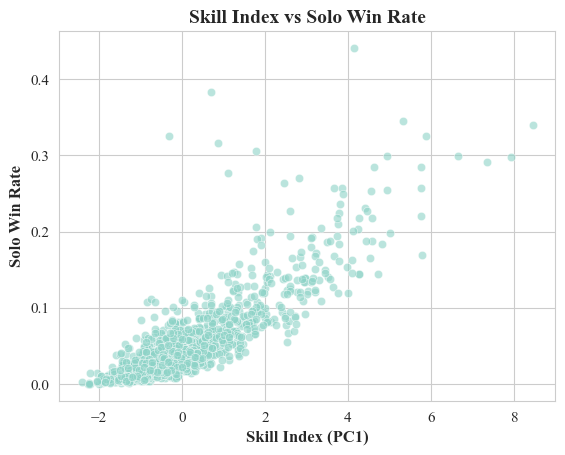

In [13]:
plt.figure()
sns.scatterplot(
    x=df["SkillIndex_PCA"],
    y=df["Solo_wr"],
    alpha=0.6
)
plt.xlabel("Skill Index (PC1)")
plt.ylabel("Solo Win Rate")
plt.title("Skill Index vs Solo Win Rate")
plt.show()

### 6. Regression-Based Skill Estimation

A linear regression model is fitted:

WR = β₀ + β₁ KD + β₂ KPM + β₃ MPM

This provides an alternative skill representation
based on predictive contribution.

In [14]:
model = LinearRegression()
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)

r2 = r2_score(y, y_pred)
r2

0.8731130298159028

In [15]:
coefficients = pd.Series(model.coef_, index=features)
coefficients

Solo kd     0.145188
Solo_kpm   -0.102008
Solo_mpm    0.009650
dtype: float64

### 7. Comparison of PCA Skill and Regression Skill

We compare:

1. Correlation of PCA-based Skill Index with win rate
2. R² of regression-based model
3. Structural similarity between loadings and regression coefficients

In [16]:
np.corrcoef(df["SkillIndex_PCA"], y_pred)[0, 1]

np.float64(0.9103055405882461)

### 8. Conclusions

1. The PCA-based Skill Index (PC1) demonstrates a strong positive relationship
   with Solo win rate, confirming that combat dominance is the primary
   behavioral driver of competitive success.

2. The linear regression model achieves R² ≈ 0.87, indicating that
   standardized behavioral variables explain a substantial proportion
   of variance in win rate.

3. Regression coefficients reveal that:
   - Solo kd has the strongest positive contribution,
   - Solo_kpm has a negative coefficient,
   - Solo_mpm has a negligible positive effect.

4. The negative coefficient of Solo_kpm suggests that raw elimination
   frequency alone does not guarantee higher win probability when KD is controlled.
   Efficiency in engagements (KD) appears more critical than volume of kills.

5. The high correlation (≈ 0.91) between PCA-based Skill Index and
   regression-based predictions confirms structural consistency
   between dimensionality reduction and predictive modeling.

6. Overall, the Skill Index derived from PC1 provides a compact,
   interpretable, and mathematically justified representation of Solo performance.

Phase I concludes that competitive success in Solo mode is primarily
driven by combat efficiency rather than survival duration or raw aggression.